<a href="https://colab.research.google.com/github/Maryam-Taherzadeh/Computational-Drug-Discovery/blob/main/project-01-predict-ic50-mdm2-p53/notebooks/mdm2_part2_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Computational Drug Discovery – MDM2–p53 Inhibitor Prediction

**Part 2: Feature Engineering & Exploratory Data Analysis (EDA)**  
Author: Maryam Taherzadeh  

---

## 📌 Project Overview

In this notebook, we extend the data preprocessing pipeline by generating molecular descriptors and performing exploratory data analysis (EDA) on the MDM2 bioactivity dataset.

We calculate physicochemical properties using RDKit and transform IC50 values into pIC50 to enable better modeling.

---

## 🎯 Objectives

- Calculate molecular descriptors (Lipinski features)
- Convert IC50 values to pIC50 scale
- Clean and normalize dataset
- Remove ambiguous data (intermediate class)
- Perform exploratory data analysis (EDA)
- Conduct statistical analysis (Mann–Whitney U test)

---

## 🧪 Methods

- RDKit for descriptor calculation
- Pandas & NumPy for data processing
- Seaborn & Matplotlib for visualization
- Statistical testing for feature relevance

---

## 📊 Output

- Final dataset with features (MW, LogP, etc.)
- pIC50 values
- EDA plots (distribution, scatter, boxplots)
- Statistical significance results
---

## **Install rdkit**




In [ ]:
!pip install rdkit

## **Load bioactivity data**

In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
df = pd.read_csv("/content/gdrive/My Drive/Colab Notebooks/data2/mdm2_preprocessed_data.csv")
df.head()
df.shape

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


(5792, 4)

## Calculate Lipinski Descriptors

Christopher Lipinski, a scientist at Pfizer, introduced a widely used rule-of-thumb for evaluating the **drug-likeness** of chemical compounds. Drug-likeness refers to whether a molecule has physicochemical properties consistent with compounds that are likely to become orally active drugs.

These properties are closely related to **ADME**, which stands for:

- **Absorption**
- **Distribution**
- **Metabolism**
- **Excretion**

Together, these describe the pharmacokinetic behavior of a compound in the body.

By analyzing many orally active FDA-approved drugs, Lipinski proposed what is now known as **Lipinski’s Rule of Five**. According to this rule, compounds are more likely to have favorable oral bioavailability if they satisfy the following criteria:

- **Molecular weight (MW)** < 500 Dalton  
- **Octanol/water partition coefficient (LogP)** < 5  
- **Hydrogen bond donors (HBD)** < 5  
- **Hydrogen bond acceptors (HBA)** < 10  

In this project, we calculate these descriptors for the MDM2 inhibitor dataset using **RDKit**. These features help us better understand the chemical space of the compounds and provide useful inputs for downstream machine learning analysis.

### **Import libraries**

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Validate SMILES using RDKit**

Not all SMILES strings are valid molecules.

Even after removing NaN:

Some strings are chemically invalid
RDKit cannot parse them

In [ ]:
df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)

# Keep only valid molecules
df = df[df['mol'].notna()].copy()

print("After RDKit validation shape:", df.shape)

After RDKit validation shape: (5792, 5)


In [ ]:
def lipinski(smiles):
    # List to store valid RDKit molecule objects
    moldata = []

    # Loop through each SMILES string
    for elem in smiles:
        # Convert SMILES string → RDKit molecule object
        mol = Chem.MolFromSmiles(elem)

        # Only keep valid molecules (skip invalid ones)
        if mol is not None:
            moldata.append(mol)

    # List to store descriptor values for each molecule
    baseData = []

    # Loop through each valid molecule
    for mol in moldata:

        # Calculate molecular weight (size of molecule)
        desc_MolWt = Descriptors.MolWt(mol)

        # Calculate LogP (lipophilicity / hydrophobicity)
        desc_MolLogP = Descriptors.MolLogP(mol)

        # Count number of hydrogen bond donors
        desc_NumHDonors = Lipinski.NumHDonors(mol)

        # Count number of hydrogen bond acceptors
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        # Store all descriptors in one row
        row = [
            desc_MolWt,
            desc_MolLogP,
            desc_NumHDonors,
            desc_NumHAcceptors
        ]

        # Add this row to the dataset
        baseData.append(row)

    # Define column names for the descriptors
    columnNames = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]

    # Convert list of rows into a pandas DataFrame
    descriptors = pd.DataFrame(baseData, columns=columnNames)

    # Return the final descriptor DataFrame
    return descriptors

In [ ]:
# Calculate Lipinski descriptors
df_lipinski = lipinski(df['canonical_smiles'])

# Check shape
print(f"Lipinski shape: {df_lipinski.shape}")

# Preview first rows
display(df_lipinski.head())

Lipinski shape: (5792, 4)


,MW,LogP,NumHDonors,NumHAcceptors
0,580.300,5.2715,2,3
1,581.193,5.5595,2,3
2,453.369,5.8230,1,2
3,551.470,6.7625,1,3
4,630.366,7.5250,1,3


In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,580.300,5.27150,2,3
1,581.193,5.55950,2,3
2,453.369,5.82300,1,2
3,551.470,6.76250,1,3
4,630.366,7.52500,1,3
...,...,...,...,...
5787,568.417,5.72350,0,8
5788,547.999,5.37852,0,8
5789,565.421,5.03750,0,8
5790,564.433,5.64250,0,7


Now, let's combine the 2 DataFrame

In [ ]:
df = df.reset_index(drop=True)
df_lipinski = df_lipinski.reset_index(drop=True)

df_combined = pd.concat([df, df_lipinski], axis=1)




In [ ]:
df_combined


,molecule_chembl_id,canonical_smiles,bioactivity_class,standard_value,mol,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL178578,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...,intermediate,1700.00,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc297e0>,580.300,5.27150,2,3
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,active,200.00,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc299a0>,581.193,5.55950,2,3
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,inactive,30000.00,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a10>,453.369,5.82300,1,2
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,inactive,13000.00,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a80>,551.470,6.76250,1,3
4,CHEMBL427316,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...,intermediate,3600.00,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29af0>,630.366,7.52500,1,3
...,...,...,...,...,...,...,...,...,...
5787,CHEMBL6014971,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,active,0.24,<rdkit.Chem.rdchem.Mol object at 0x7e8fb4151380>,568.417,5.72350,0,8
5788,CHEMBL5805098,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,active,0.69,<rdkit.Chem.rdchem.Mol object at 0x7e8fb41513f0>,547.999,5.37852,0,8
5789,CHEMBL6045300,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,active,2.86,<rdkit.Chem.rdchem.Mol object at 0x7e8fb4151460>,565.421,5.03750,0,8
5790,CHEMBL6055628,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,active,0.25,<rdkit.Chem.rdchem.Mol object at 0x7e8fb41514d0>,564.433,5.64250,0,7


In [ ]:
df_combined.standard_value.describe()

,standard_value
count,5792.000000
mean,3176.365748
std,15400.324179
min,0.040000
25%,2.594750
50%,14.940000
75%,190.875000
max,295000.000000


What this tells you (VERY IMPORTANT)


1️⃣ Data is highly skewed

👉 Look:

median = 14.9
mean = 3176 😳

➡️ mean >> median → right-skewed distribution

2️⃣ Huge range

👉 From:

0.04 nM (very strong)
to
295,000 nM (very weak)

➡️ That’s millions difference

3️⃣ High standard deviation
std = 15400

👉 Means:

data is very spread out
unstable for ML
💡 So what should you conclude?

👉 You NEED:

✔ normalization (optional but good)
to cap extreme values

✔ pIC50 (VERY important)
to compress scale
to make distribution smoother

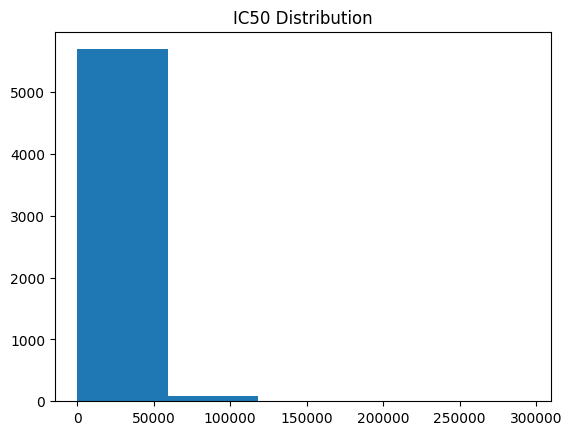

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df_combined['standard_value'], bins=5)
plt.title("IC50 Distribution")
plt.show()

### **Convert IC50 to pIC50**


To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [ ]:

import pandas as pd

def norm_value(df):
    df = df.copy()  # avoid modifying original data
    norm = []

    for i in df['standard_value']:
        if i > 100000000:
            i = 100000000
        norm.append(i)

    df['standard_value_norm'] = norm
    df = df.drop('standard_value', axis=1)

    return df





In [ ]:
import numpy as np

def pIC50(df):
    pIC50_vals = []

    for i in df['standard_value_norm']:
        molar = i * (10**-9)  # Converts nM → M
        pIC50_vals.append(-np.log10(molar))

    df['pIC50'] = pIC50_vals
    df = df.drop('standard_value_norm', axis=1)

    return df

In [ ]:

df_norm = norm_value(df_combined)
df_final = pIC50(df_norm)

df_final.head()

,molecule_chembl_id,canonical_smiles,bioactivity_class,mol,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL178578,O=C(O)[C@H](c1ccccc1)N1C(=O)c2cc(I)ccc2NC(=O)[...,intermediate,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc297e0>,580.300,5.2715,2,3,5.769551
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc299a0>,581.193,5.5595,2,3,6.698970
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a10>,453.369,5.8230,1,2,4.522879
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a80>,551.470,6.7625,1,3,4.886057
4,CHEMBL427316,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2Br)N(CC...,intermediate,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29af0>,630.366,7.5250,1,3,5.443697


In [ ]:
df_combined.standard_value.describe()

,standard_value
count,5792.000000
mean,3176.365748
std,15400.324179
min,0.040000
25%,2.594750
50%,14.940000
75%,190.875000
max,295000.000000


In [ ]:
df_final.pIC50.describe()

,pIC50
count,5792.000000
mean,7.575133
std,1.402104
min,3.530178
25%,6.719255
50%,7.825650
75%,8.585906
max,10.397940


### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [ ]:
df_2class = df_final[df_final.bioactivity_class != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,bioactivity_class,mol,MW,LogP,NumHDonors,NumHAcceptors,pIC50
1,CHEMBL361103,O=C(O)[C@H](c1ccc(Cl)cc1)N1C(=O)c2cc(I)ccc2NC(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc299a0>,581.193,5.55950,2,3,6.698970
2,CHEMBL182051,C[C@H](c1ccc(Cl)cc1)N(C(=O)/C=C/c1ccccc1)[C@H]...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a10>,453.369,5.82300,1,2,4.522879
3,CHEMBL360540,C[C@H](c1ccc(Cl)cc1)N1C(=O)C=C(c2ccccc2)N(CCCC...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29a80>,551.470,6.76250,1,3,4.886057
5,CHEMBL425528,O=C(O)C(c1ccccc1)N(Cc1ccc(C(F)(F)F)cc1)C(=O)c1...,inactive,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29b60>,539.291,5.77830,1,2,4.823909
6,CHEMBL199341,C=C(C(=O)O)C(CCCCCC)C(=O)O,active,<rdkit.Chem.rdchem.Mol object at 0x7e8f8cc29bd0>,214.261,2.29840,2,2,7.301030
...,...,...,...,...,...,...,...,...,...
5787,CHEMBL6014971,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb4151380>,568.417,5.72350,0,8,9.619789
5788,CHEMBL5805098,COc1ncc(-c2nc3c(n2C(C)C)[C@H](c2ccc(Cl)cc2)N(c...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb41513f0>,547.999,5.37852,0,8,9.161151
5789,CHEMBL6045300,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb4151460>,565.421,5.03750,0,8,8.543634
5790,CHEMBL6055628,COc1ncc(-c2nc3c(n2C(C)C)[C@@H](c2ccc(Cl)cc2)N(...,active,<rdkit.Chem.rdchem.Mol object at 0x7e8fb41514d0>,564.433,5.64250,0,7,9.602060


---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

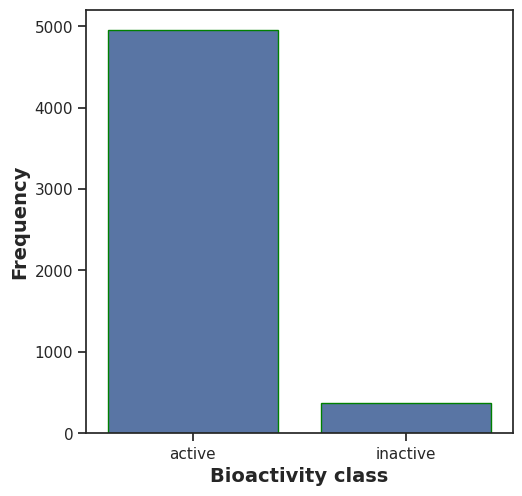

In [ ]:
#Creates a plot with size( 5.5,5.5)

plt.figure(figsize=(5.5, 5.5))
#countplot → counts how many samples in each class
sns.countplot(x='bioactivity_class', data=df_2class, edgecolor='green')
# Label for x-axis: X-axis → bioactivity_class
plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
# Label for y-axis: Frequency (number of molecules)
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
# Saves the plot as a PDF file
plt.savefig('plot_bioactivity_class.pdf')

### Note:

#####One class has many more samples than the other

The dataset is highly imbalanced, with significantly more active compounds than inactive ones, which may bias the model toward the majority class.

In [ ]:
df_2class.corr(numeric_only=True)

,MW,LogP,NumHDonors,NumHAcceptors,pIC50
MW,1.000000,-0.463645,0.833401,0.737062,0.019846
LogP,-0.463645,1.000000,-0.708319,-0.600588,0.205739
NumHDonors,0.833401,-0.708319,1.000000,0.643708,-0.177858
NumHAcceptors,0.737062,-0.600588,0.643708,1.000000,0.103579
pIC50,0.019846,0.205739,-0.177858,0.103579,1.000000



**“The correlation matrix shows that none of the physicochemical descriptors strongly correlate with pIC50, indicating that bioactivity is likely governed by more complex, non-linear relationships. Additionally, strong correlations between features suggest multicollinearity.”**


### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

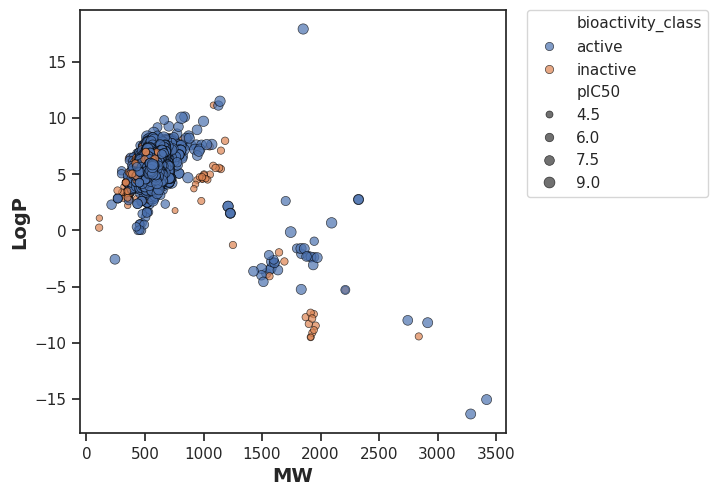

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='bioactivity_class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

The scatter plot shows that active and inactive compounds occupy overlapping chemical space in terms of MW and LogP, and there is no clear trend linking these features to bioactivity or potency.

 pIC50 (size of dots)

Bigger dots = stronger compounds

 They are:

not concentrated in one region
spread across the plot

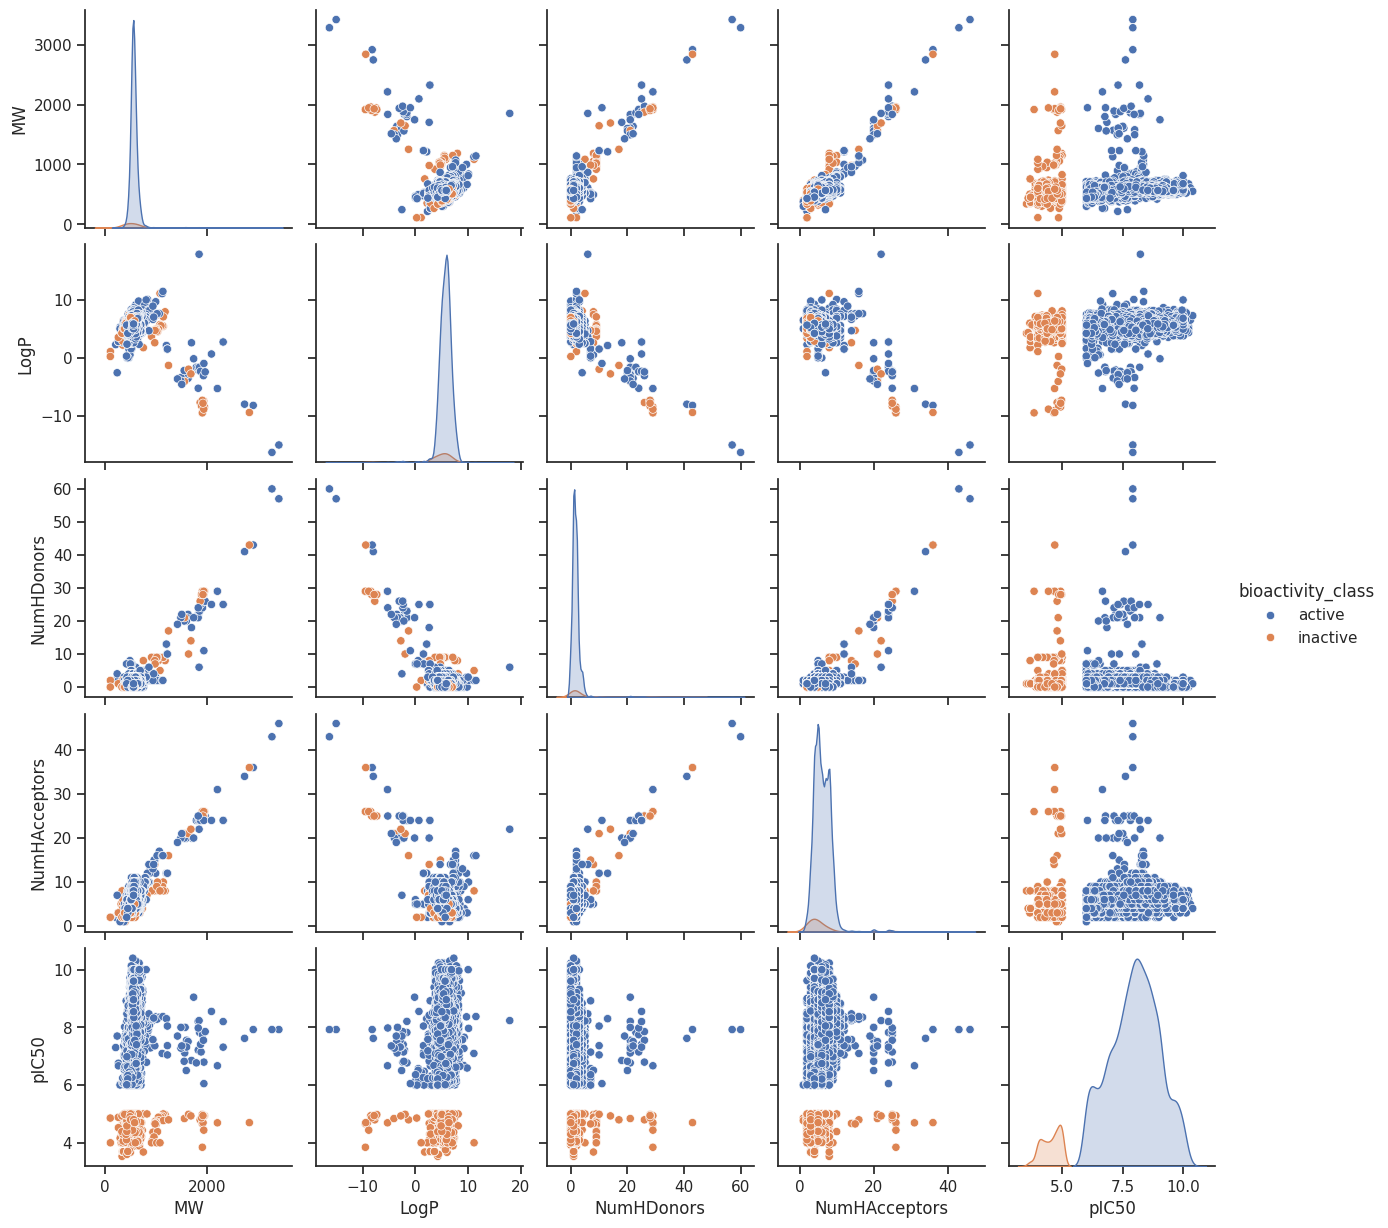

In [ ]:
import seaborn as sns

sns.pairplot(
    df_2class[['MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'pIC50', 'bioactivity_class']],
    hue='bioactivity_class'
)

## 🔬 Pairplot Analysis: Key Insights

### 📊 Overview

The pairplot visualization provides insight into the relationships between physicochemical descriptors and bioactivity. It highlights how well these features can distinguish between **active** and **inactive** compounds.

---

### 1️⃣ pIC50 vs All Features (Most Important)

The bottom row of the pairplot shows **pIC50 against all other features**.

* 🔵 **Active compounds**: high pIC50 values (~6–10)
* 🟠 **Inactive compounds**: low pIC50 values (~4–5)

👉 There is a **clear vertical separation** between the two classes.

**Interpretation:**

* ✔ pIC50 strongly separates active and inactive compounds
* ✔ Confirms correct labeling of bioactivity classes

---

### 2️⃣ LogP vs Other Features

Examining LogP against hydrogen bond features:

* LogP vs NumHDonors
* LogP vs NumHAcceptors

👉 A **negative trend** is observed:

* Higher LogP → fewer donors/acceptors
* Lower LogP → more donors/acceptors

**Interpretation:**

* ✔ Hydrophobic molecules tend to have fewer polar groups
* ✔ This aligns with chemical intuition (hydrophobic vs polar balance)

---

### 3️⃣ NumHDonors vs NumHAcceptors

A strong diagonal pattern is visible:

👉 As donors increase, acceptors also increase

**Interpretation:**

* ✔ Strong positive correlation
* ⚠️ Indicates **multicollinearity** (redundant features)

---

### 4️⃣ Physicochemical Features vs pIC50

Looking at:

* LogP vs pIC50
* NumHDonors vs pIC50
* NumHAcceptors vs pIC50

👉 Observations:

* ❌ No clear trend
* ❌ No separation between active and inactive compounds

**Interpretation:**

* These features **do not directly predict pIC50**
* Limited predictive power when used alone

---

### 🎯 Final Conclusion

The pairplot shows that:

* ✔ pIC50 effectively separates bioactivity classes
* ✔ Physicochemical descriptors are strongly inter-correlated
* ❌ These descriptors have weak relationships with pIC50

👉 This indicates that **simple physicochemical features are insufficient** for predicting bioactivity, and more advanced descriptors (e.g., molecular fingerprints or structural features) are required.

---

### 🚀 Key Takeaway

> While pIC50 clearly distinguishes active and inactive compounds, the current set of descriptors (LogP, NumHDonors, NumHAcceptors) lacks sufficient predictive power, highlighting the need for more informative features in modeling.


#### **pIC50 value**

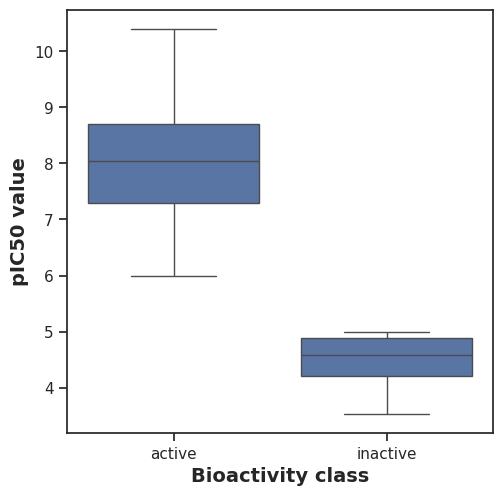

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt


plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):

  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  active = df[df.bioactivity_class == 'active']
  active = active[descriptor]

  selection = [descriptor, 'bioactivity_class']
  df = df_2class[selection]
  inactive = df[df.bioactivity_class == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,1813530.0,2.415158e-224,0.05,Different distribution (reject H0)


#### **MW**

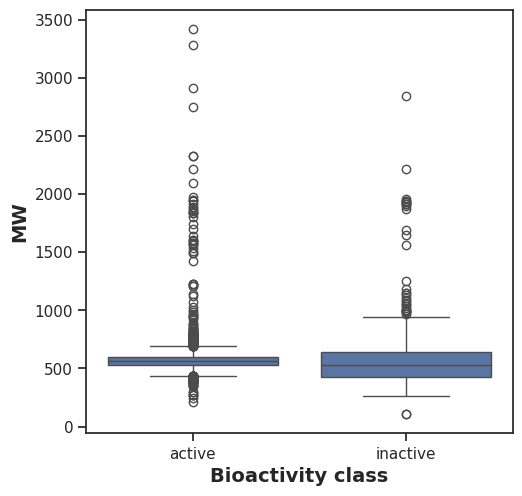

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,1051768.0,3.172631e-07,0.05,Different distribution (reject H0)


#### **LogP**

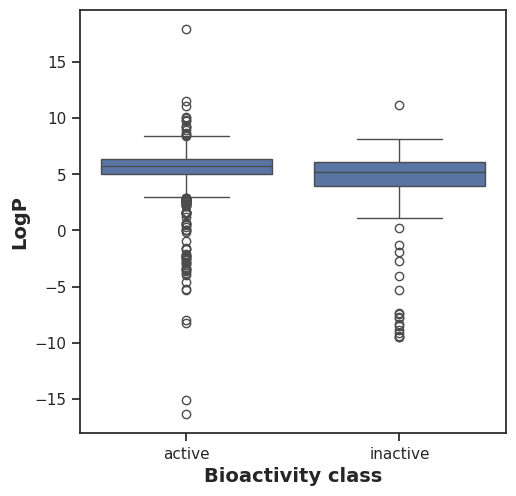

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,1143322.5,7.356101e-17,0.05,Different distribution (reject H0)


#### **NumHDonors**

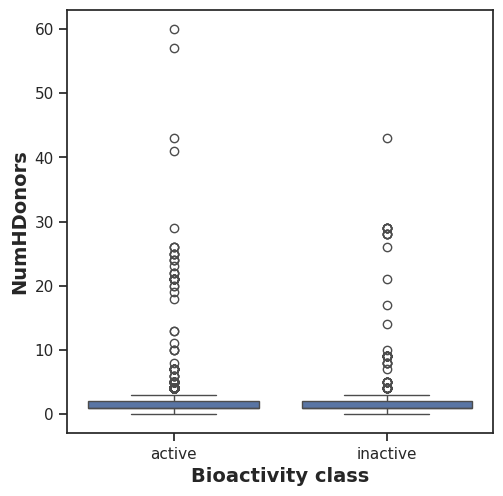

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,857295.5,0.063584,0.05,Same distribution (fail to reject H0)


#### **NumHAcceptors**

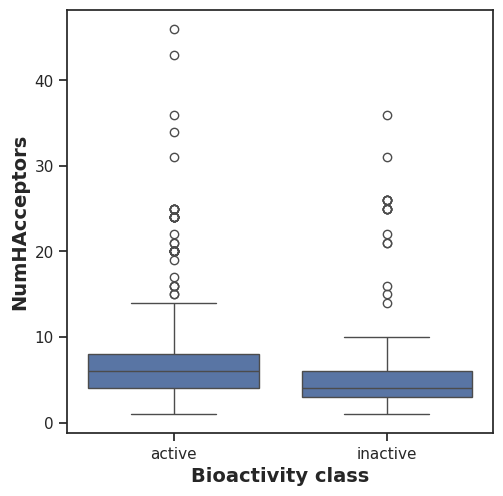

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'bioactivity_class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,1247929.5,4.446567e-34,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

### Lipinski’s Descriptors (Mann–Whitney U Test)

The Mann–Whitney U test was applied to evaluate differences between active and inactive compounds.

- **MW, LogP, and NumHAcceptors** showed statistically significant differences (p < 0.05) between the two classes.
- **NumHDonors** showed no statistically significant difference (p > 0.05).

However, despite statistical significance, these descriptors exhibit weak correlation with pIC50 and do not provide strong predictive power individually. This suggests that bioactivity is influenced by more complex structural features rather than simple physicochemical properties alone.

## 📊 Box Plot Analysis

### 🔬 pIC50 Values

The box plot of **pIC50** shows a clear separation between **active** and **inactive** compounds.

* **Actives** exhibit higher pIC50 values (≈ 6–10), indicating stronger potency
* **Inactives** exhibit lower pIC50 values (≈ 3.5–5), indicating weaker activity

A **statistically significant difference** is observed between the two groups, as confirmed by the Mann–Whitney U test (p ≪ 0.05).

👉 This is expected because the bioactivity classes were defined using IC50 thresholds:

* IC50 < 1,000 nM → **Active** (pIC50 > 6)
* IC50 > 10,000 nM → **Inactive** (pIC50 < 5)

✔ Therefore, pIC50 inherently reflects the bioactivity classification.

---

### ⚗️ Lipinski’s Descriptors

The four Lipinski descriptors analyzed were:

* Molecular Weight (**MW**)
* LogP (**LogP**)
* Number of H-bond Donors (**NumHDonors**)
* Number of H-bond Acceptors (**NumHAcceptors**)

---

### 🔍 Observations

* **MW**:

  * ✔ Shows a **statistically significant difference** between actives and inactives (p < 0.05)

* **LogP**:

  * ✔ Also shows a **statistically significant difference** (p < 0.05)
  * ⚠️ However, the separation is weak visually and correlation with pIC50 is low

* **NumHAcceptors**:

  * ✔ Shows a **statistically significant difference** (p < 0.05)

* **NumHDonors**:

  * ❌ Shows **no statistically significant difference** (p > 0.05)

---

### ⚠️ Important Insight

Although MW, LogP, and NumHAcceptors show statistical significance:

* Their **correlation with pIC50 is weak**
* They do not provide strong predictive power individually

👉 This highlights an important concept:

> **Statistical significance does not necessarily imply predictive usefulness.**

---

### 🎯 Conclusion

* pIC50 strongly separates active and inactive compounds (as expected)
* NumHDonors does not differentiate between classes
* Other descriptors show statistical differences but limited predictive strength

👉 These results suggest that **more informative features (e.g., molecular fingerprints or advanced descriptors)** are required for accurate bioactivity prediction.

---


## **Zip files**

In [ ]:
!zip results.zip *.csv *.pdf

  adding: mannwhitneyu_LogP.csv (deflated 9%)
  adding: mannwhitneyu_MW.csv (deflated 9%)
  adding: mannwhitneyu_NumHAcceptors.csv (deflated 10%)
  adding: mannwhitneyu_NumHDonors.csv (deflated 10%)
  adding: mannwhitneyu_pIC50.csv (deflated 10%)
  adding: plot_bioactivity_class.pdf (deflated 38%)
  adding: plot_ic50.pdf (deflated 36%)
  adding: plot_LogP.pdf (deflated 38%)
  adding: plot_MW.pdf (deflated 34%)
  adding: plot_MW_vs_LogP.pdf (deflated 1%)
  adding: plot_NumHAcceptors.pdf (deflated 39%)
  adding: plot_NumHDonors.pdf (deflated 37%)


In [ ]:
!ls

gdrive				plot_LogP.pdf
mannwhitneyu_LogP.csv		plot_MW.pdf
mannwhitneyu_MW.csv		plot_MW_vs_LogP.pdf
mannwhitneyu_NumHAcceptors.csv	plot_NumHAcceptors.pdf
mannwhitneyu_NumHDonors.csv	plot_NumHDonors.pdf
mannwhitneyu_pIC50.csv		results.zip
plot_bioactivity_class.pdf	sample_data
plot_ic50.pdf
